<a href="https://colab.research.google.com/github/BandanaSingha24/AI-ML-DL-in-Cancer-Genomics/blob/main/Genomics_TCGA_BRCA_SVM_Rendom%20forest_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -o final_clustered_dataset.csv https://raw.githubusercontent.com/BandanaSingha24/AI-ML-DL-in-Cancer-Genomics/refs/heads/main/07_ML_Kmeans_Hierarchical_Consensus_Clustering/Data/final_clustered_data.csv

In [2]:
import pandas as pd
# step 1: Loding dataset
df= pd.read_csv('final_clustered_data.csv')

print(df.head())

      UMAP1     UMAP2  cluster
0  1.845781  3.529707        1
1  2.171704  4.253536        1
2  1.468105  4.292963        1
3  1.684058  3.277272        2
4  1.751417  4.405654        1


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


# --- STEP 2:Random Forest (Model Training and Evaluation)

# Defining features (X) and target (y)
# UMAP1 and UMAP2 are features, while cluster is the target
X = df[['UMAP1', 'UMAP2']]
y = df['cluster']

# Splitting data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initializing the Random Forest classifier
model = RandomForestClassifier()

# Training the model on the training data
model.fit(X_train, y_train)

# Checking the accuracy of the model
accuracy = model.score(X_test, y_test)
print("Model accuracy:", accuracy)


Model accuracy: 0.9882154882154882


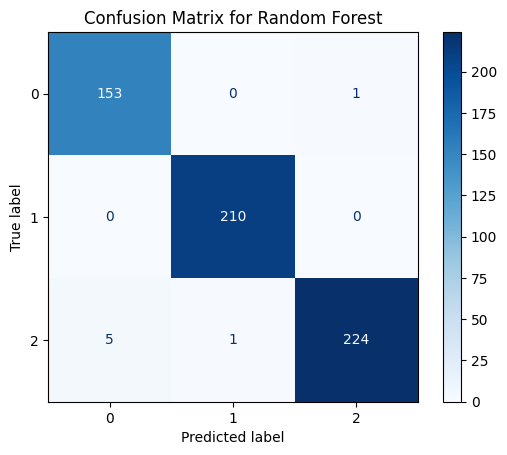

In [4]:
# Random forest (Confusion Matrix)

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#(Predicting the clusters)
y_pred = model.predict(X_test)

# Confusion Matrix (tell about model accuracy)
cm = confusion_matrix(y_test, y_pred)

# graf format
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Random Forest")
plt.show()


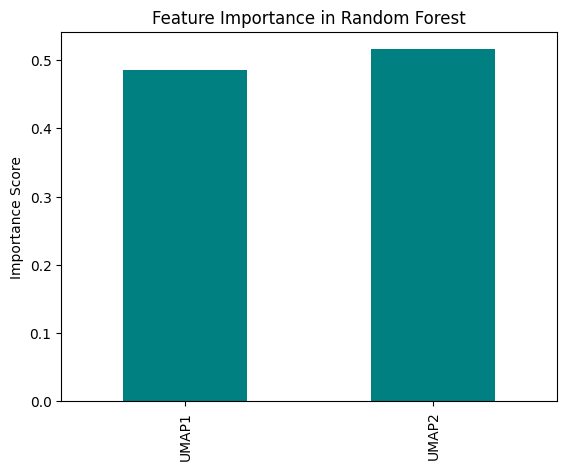

In [5]:
# Random Forest(Feature Importance)
# this helps in identifying the key genomic drivers(UMAP dimension) used by the classidier
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.plot(kind='bar', color='teal')

plt.title("Feature Importance in Random Forest")
plt.ylabel("Importance Score")
plt.show()

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# --- STEP 3: SVM (Model Training and Evaluation) ---

# Initializing the SVM model with a linear kernel
svm_model = SVC(kernel='linear')

# Training the model on the training data
svm_model.fit(X_train, y_train)

# Predicting the clusters for the test set
y_pred_svm = svm_model.predict(X_test)

# Checking the accuracy of the SVM model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Model accuracy:", svm_accuracy)


SVM Model accuracy: 0.9949494949494949


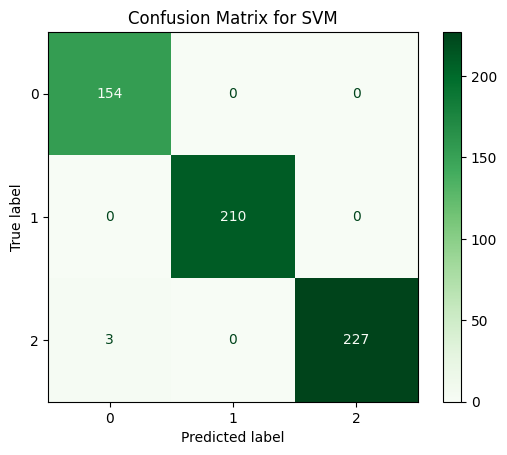

In [7]:
# SVM (Confusion Matrix) ---
# Generating the confusion matrix to evaluate SVM performance
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plotting the confusion matrix as a heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot(cmap='Greens')
plt.title("Confusion Matrix for SVM")
plt.show()


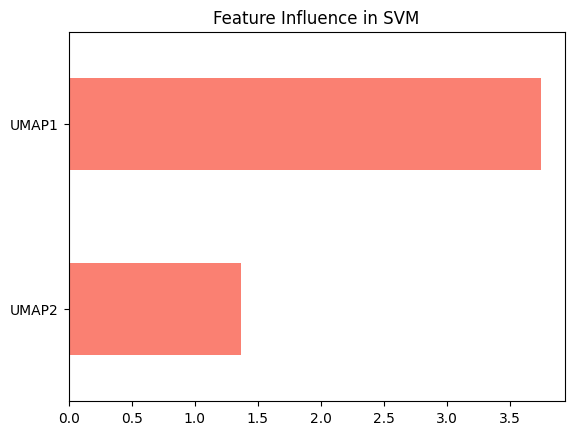

In [8]:
# SVM  (Feature Influence) ---
# Calculating feature influence based on model coefficients
# This helps identify which feature (UMAP1 or UMAP2) is more influential
importance = pd.Series(svm_model.coef_[0], index=X.columns)

# Visualizing feature influence as a bar chart
importance.abs().sort_values().plot(kind='barh', color='salmon')
plt.title("Feature Influence in SVM")
plt.show()


XGBoost Model accuracy: 0.9797979797979798


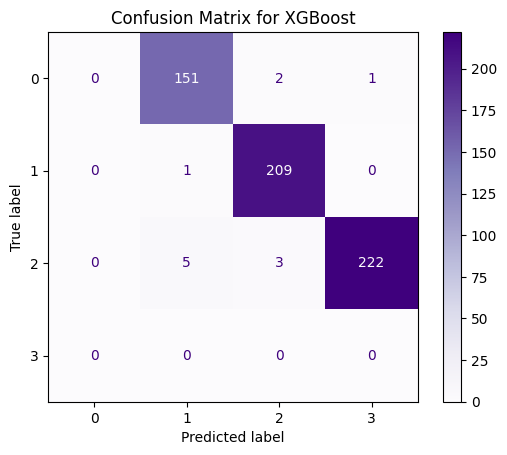

In [13]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# step 4: XGBoost (Model Training and Evaluation) ---

# Initializing XGBoost model
# We set objective to 'multi:softmax' for 3 classes
xgb_model = XGBClassifier(eval_metric='mlogloss')

# Training the model
xgb_model.fit(X_train, y_train)

# Predicting
y_pred_xgb = xgb_model.predict(X_test)

# Checking accuracy
print("XGBoost Model accuracy:", accuracy_score(y_test, y_pred_xgb))


# XGBoost (Confusion Matrix)--------------
# Generating and plotting the confusion matrix
cm_xgb = confusion_matrix(y_test - 1, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot(cmap='Purples') # Purple color for a distinct look
plt.title("Confusion Matrix for XGBoost")
plt.show()

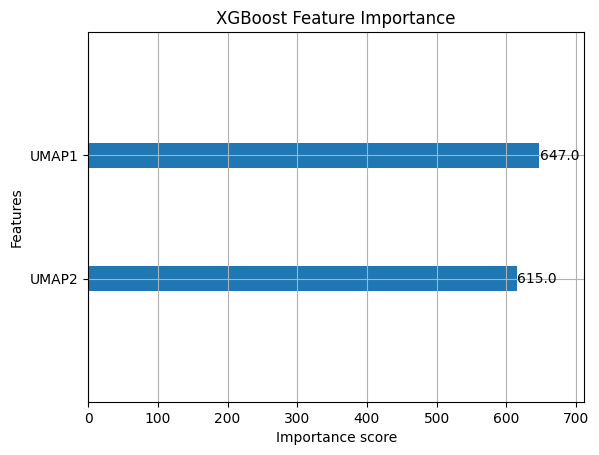

In [14]:
# XGBoost (Feature Importance Analysis )---
# Visualizing the importance scores to understand which UMAP features
# have the most influence on the XGBoost model's predictions.

import xgboost as xgb
import matplotlib.pyplot as plt

# Plotting the feature importance
xgb.plot_importance(xgb_model)
plt.title("XGBoost Feature Importance")
plt.show()

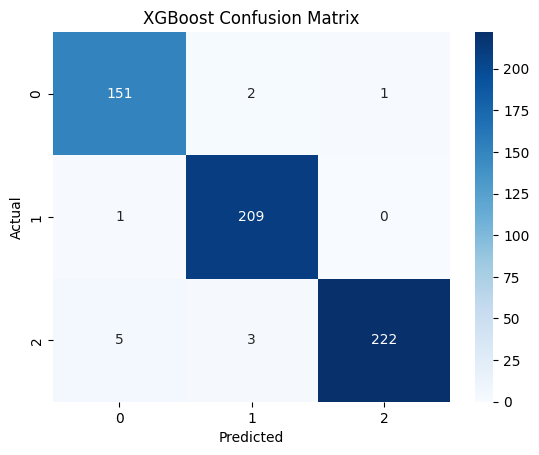

In [20]:
# XGBoost Model Evaluation ---
# Generating the confusion matrix to visualize prediction accuracy across clusters
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plotting the confusion matrix as a heatmap for better interpretability
# 'Blues' colormap is used to highlight the diagonal correctly predicted samples
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
from sklearn.metrics import roc_auc_score

# step 5:  Module Evaluatio (Calculating ROC-AUC Score) ---
# Calculating the ROC-AUC score to evaluate the model's ability to distinguish between classes
# 'multi_class=ovr' (One-vs-Rest) is used for multiclass classification
y_pred_proba = xgb_model.predict_proba(X_test)
auc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', labels=xgb_model.classes_)
print(f"XGBoost ROC-AUC Score: {auc_score}")

XGBoost ROC-AUC Score: 0.9997591679656898


In [24]:
# Module Evaluation (F1)

from sklearn.metrics import f1_score, recall_score, precision_score
import pandas as pd

# List of models to evaluate
models = [('Random Forest', model), ('SVM', svm_model), ('XGBoost', xgb_model)]
results = []

for name, model_instance in models:
    # Predict and adjust labels to match the test set (if needed)
    y_pred = model_instance.predict(X_test)

    # Calculate metrics
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, precision, recall, f1])

# Create a professional summary table
df_results = pd.DataFrame(results, columns=['Model', 'Precision', 'Recall', 'F1-Score'])
print("--- Final Model Comparison Table ---")
print(df_results)

--- Final Model Comparison Table ---
           Model  Precision    Recall  F1-Score
0  Random Forest   0.988399  0.988215  0.988217
1            SVM   0.995046  0.994949  0.994957
2        XGBoost   0.980095  0.979798  0.979802


In [25]:
df_results.to_csv('model_evaluation_table.csv', index=False)
